In [ ]:
import kagglehub


path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Path to dataset files: /kaggle/input/cell-images-for-detecting-malaria


In [ ]:
import os
path="/kaggle/input/cell-images-for-detecting-malaria"
dataset_path = path + "/cell_images"

images = []
labels = []

for label_name in ["Parasitized", "Uninfected"]:
    folder = os.path.join(dataset_path, label_name)

    for file in os.listdir(folder):
        if not file.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        images.append(os.path.join(folder, file))

        if label_name == "Parasitized":
            labels.append(1)
        else:
            labels.append(0)

print(len(images))
print(len(labels))

27558
27558


In [ ]:
from collections import Counter

print(Counter(labels))

Counter({1: 13779, 0: 13779})


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'image': images,
    'label': labels
})

print(df['label'].value_counts())

label
1    13779
0    13779
Name: count, dtype: int64


In [ ]:
df.sample(4)

,image,label
14851,/kaggle/input/cell-images-for-detecting-malari...,0
17662,/kaggle/input/cell-images-for-detecting-malari...,0
17634,/kaggle/input/cell-images-for-detecting-malari...,0
2700,/kaggle/input/cell-images-for-detecting-malari...,1


In [ ]:
df.head(3)

,image,label
0,/kaggle/input/cell-images-for-detecting-malari...,1
1,/kaggle/input/cell-images-for-detecting-malari...,1
2,/kaggle/input/cell-images-for-detecting-malari...,1


In [ ]:
x=df['image']
y=df['label']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.head(2)



,image
3381,/kaggle/input/cell-images-for-detecting-malari...
24403,/kaggle/input/cell-images-for-detecting-malari...


In [ ]:
import numpy as np

In [ ]:
pip install opencv-python

In [ ]:
x_train.head(4)

,image
3381,/kaggle/input/cell-images-for-detecting-malari...
24403,/kaggle/input/cell-images-for-detecting-malari...
14319,/kaggle/input/cell-images-for-detecting-malari...
22676,/kaggle/input/cell-images-for-detecting-malari...


In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 16


train_df = pd.DataFrame({'image': x_train, 'label': y_train.astype(str)})
test_df = pd.DataFrame({'image': x_test, 'label': y_test.astype(str)})


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 22046 validated image filenames belonging to 2 classes.
Found 5512 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model=Sequential()
model.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))

model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,871,489 (64.36 MB)

 Trainable params: 16,871,489 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)


Epoch 1/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 310s 220ms/step - accuracy: 0.6171 - loss: 0.6417 - val_accuracy: 0.9100 - val_loss: 0.2673
Epoch 2/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 147s 107ms/step - accuracy: 0.9336 - loss: 0.2083 - val_accuracy: 0.9505 - val_loss: 0.1520
Epoch 3/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 152s 110ms/step - accuracy: 0.9456 - loss: 0.1732 - val_accuracy: 0.9539 - val_loss: 0.1474
Epoch 4/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 150s 109ms/step - accuracy: 0.9480 - loss: 0.1649 - val_accuracy: 0.9585 - val_loss: 0.1321
Epoch 5/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - accuracy: 0.9501 - loss: 0.1622 - val_accuracy: 0.9610 - val_loss: 0.1274
Epoch 6/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 155s 113ms/step - accuracy: 0.9511 - loss: 0.1583 - val_accuracy: 0.9566 - val_loss: 0.1586
Epoch 7/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 155s 112ms/step - accuracy: 0.9524 - loss: 0.1543 - val_accuracy: 0.9604 - val_loss: 0.1249
Epoch 8/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 161s 117ms/step - ac

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/malaria_model.h5')

Mounted at /content/drive


In [ ]:
class_names = {0: "Uninfected", 1: "Parasitized"}

predictions = model.predict(test_generator)
predicted_labels = (predictions > 0.5).astype(int).flatten()

for label in predicted_labels:
    print(class_names[label])

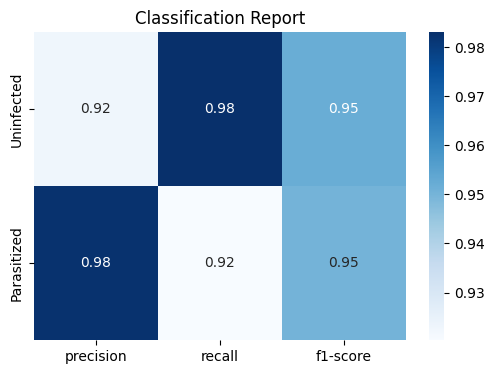

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test, predicted_labels,
    target_names=['Uninfected', 'Parasitized'],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[['Uninfected', 'Parasitized'], ['precision', 'recall', 'f1-score']]

plt.figure(figsize=(6, 4))
sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.2f')
plt.title('Classification Report')
plt.show()

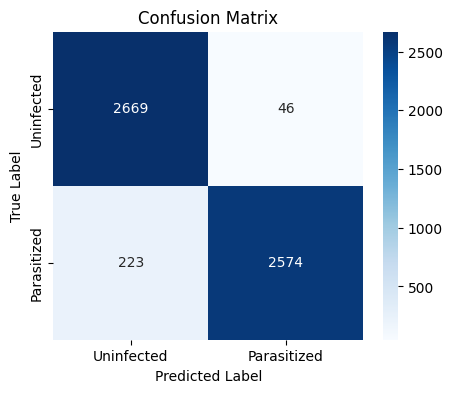

In [ ]:

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()